# DBA5101 Project 1 - Estimation of Demand

## Imports

In [44]:
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import statsmodels.api as sm

## Data Processing

In [45]:
DATA_PATH = Path("../data/Data-GP1-revised-final.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,num_seats_total,mean_net_ticket_price,Dept_Date,Purchase_Date,Train_Number_All,isNormCabin,isReturn,isOneway,Customer_Cat
0,1,188.663422,10/9/19,10/10/18,A,1,0,0,A
1,1,358.428869,5/27/19,6/6/18,B,0,1,0,A
2,1,356.372684,5/31/20,6/17/19,B,0,1,0,A
3,1,396.370505,12/10/19,12/27/18,C,0,1,0,A
4,1,364.264552,5/31/20,6/19/19,B,0,1,0,A


In [46]:
df.isna().sum()

num_seats_total          0
mean_net_ticket_price    0
Dept_Date                0
Purchase_Date            0
Train_Number_All         0
isNormCabin              0
isReturn                 0
isOneway                 0
Customer_Cat             0
dtype: int64

In [47]:
# Convert to datetime
df["Dept_Date"] = pd.to_datetime(df["Dept_Date"], format="%m/%d/%y")
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"], format="%m/%d/%y")

### No Aggregation

In [48]:
non_agg_df = df.copy(deep=True)
non_agg_df = non_agg_df.rename(columns={
    "mean_net_ticket_price": "price",
    "num_seats_total": "quantity"
})

# Add derived features
non_agg_df["days_in_advance"] = (non_agg_df["Dept_Date"] - non_agg_df["Purchase_Date"]).dt.days
non_agg_df["dept_month_of_year"] = non_agg_df["Dept_Date"].dt.month
non_agg_df["dept_day_of_week"] = non_agg_df["Dept_Date"].dt.day_name()
non_agg_df["ln_price"] = np.log(non_agg_df["price"])
non_agg_df["ln_quantity"] = np.log(non_agg_df["quantity"])

non_agg_df = non_agg_df.drop(columns=["Dept_Date", "Purchase_Date"])

non_agg_df = non_agg_df[[
    "quantity",
    "ln_quantity",
    "price",
    "ln_price",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat",
    "days_in_advance",
    "dept_month_of_year",
    "dept_day_of_week"
]]

non_agg_df = non_agg_df.rename(columns={
    "Train_Number_All": "train_num",
    "isNormCabin": "is_norm_cabin",
    "isReturn": "is_return",
    "isOneway": "is_oneway",
    "Customer_Cat": "customer_cat"
})

In [49]:
non_agg_df

,quantity,ln_quantity,price,ln_price,train_num,is_norm_cabin,is_return,is_oneway,customer_cat,days_in_advance,dept_month_of_year,dept_day_of_week
0,1,0.000000,188.663422,5.239965,A,1,0,0,A,364,10,Wednesday
1,1,0.000000,358.428869,5.881730,B,0,1,0,A,355,5,Monday
2,1,0.000000,356.372684,5.875977,B,0,1,0,A,349,5,Sunday
3,1,0.000000,396.370505,5.982349,C,0,1,0,A,348,12,Tuesday
4,1,0.000000,364.264552,5.897880,B,0,1,0,A,347,5,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...
209692,4,1.386294,468.650069,6.149856,L,0,0,0,B,0,3,Tuesday
209693,1,0.000000,468.659177,6.149876,J,0,0,1,B,0,12,Friday
209694,1,0.000000,668.061946,6.504381,J,0,0,0,B,0,6,Sunday
209695,2,0.693147,381.438513,5.943950,L,0,0,0,B,0,1,Thursday


In [50]:
non_agg_df.head()

,quantity,ln_quantity,price,ln_price,train_num,is_norm_cabin,is_return,is_oneway,customer_cat,days_in_advance,dept_month_of_year,dept_day_of_week
0,1,0.0,188.663422,5.239965,A,1,0,0,A,364,10,Wednesday
1,1,0.0,358.428869,5.881730,B,0,1,0,A,355,5,Monday
2,1,0.0,356.372684,5.875977,B,0,1,0,A,349,5,Sunday
3,1,0.0,396.370505,5.982349,C,0,1,0,A,348,12,Tuesday
4,1,0.0,364.264552,5.897880,B,0,1,0,A,347,5,Sunday


In [51]:
non_agg_df.shape

(209697, 12)

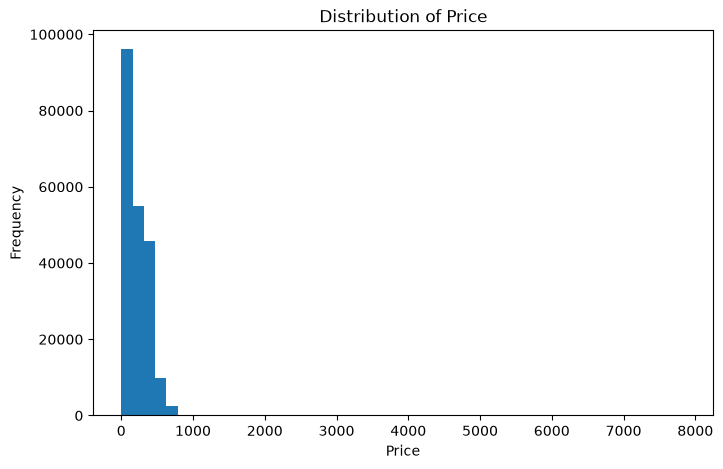

In [52]:
# Distribution of Price (P)
plt.figure(figsize=(8, 5))
plt.hist(non_agg_df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")
plt.show()

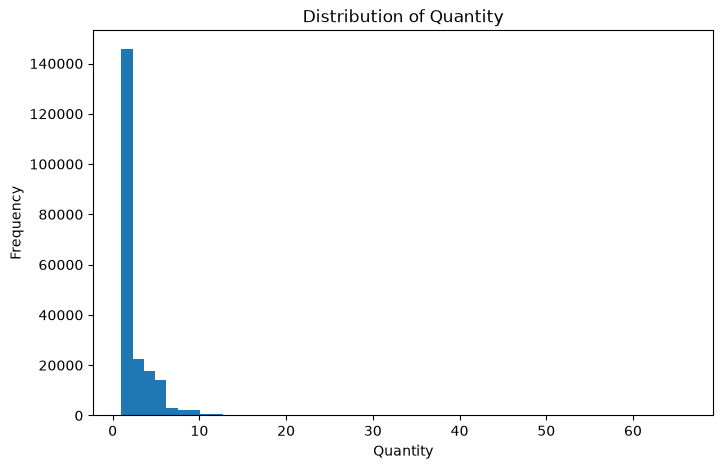

In [53]:
# Distribution of Quantity (Q)
plt.figure(figsize=(8, 5))
plt.hist(non_agg_df["quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

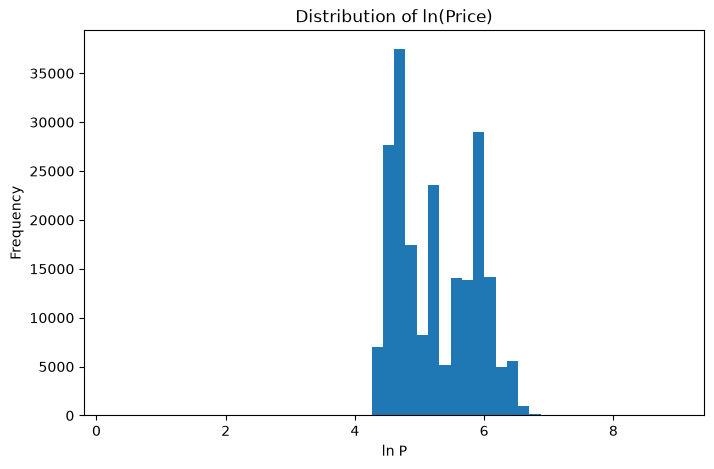

In [54]:
# Distribution of Log of Price (ln P)
plt.figure(figsize=(8, 5))
plt.hist(non_agg_df["ln_price"], bins=50)
plt.xlabel("ln P")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Price)")
plt.show()

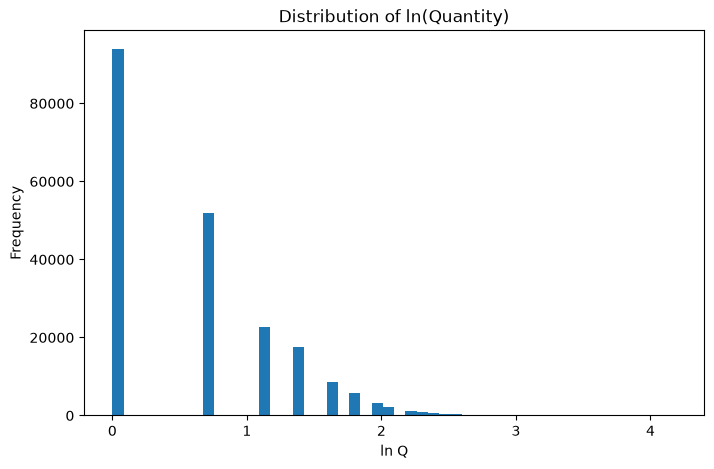

In [55]:
# Distribution of Log of Quantity (ln Q)
plt.figure(figsize=(8, 5))
plt.hist(non_agg_df["ln_quantity"], bins=50)
plt.xlabel("ln Q")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Quantity)")
plt.show()

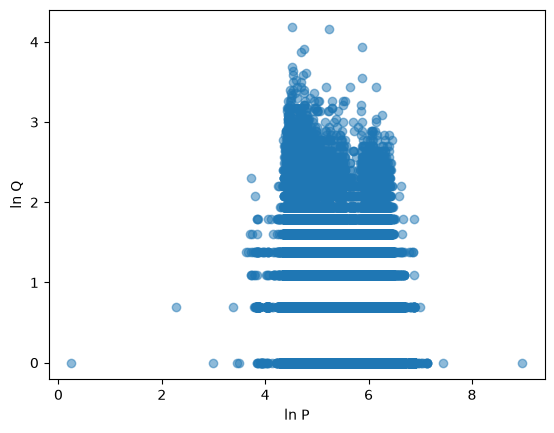

In [56]:
# Scatter plot of ln Q against ln P
plt.scatter(non_agg_df["ln_price"], non_agg_df["ln_quantity"], alpha=0.5)
plt.xlabel("ln P")
plt.ylabel("ln Q")
plt.show()

### With Aggregation

In [57]:
# Find total amount paid for aggregation
df["total_amt_paid"] = df["num_seats_total"] * df["mean_net_ticket_price"]
df = df.drop(columns=["mean_net_ticket_price"])

# Reorder columns
df = df[[
    "Dept_Date",
    "Purchase_Date",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat",
    "total_amt_paid",
    "num_seats_total"
]]

In [58]:
# We aggregate by ("Dept_Date", "Purchase_Date", "Train_Number_All", "isNormCabin", "isReturn", "isOneway", "Customer_Cat")
# Each unique tuple is taken to be:
# - Same customer type
# - Same train ride
# - Purchased at the same time
# This corresponds to one data point

group_cols = [
    "Dept_Date",
    "Purchase_Date",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat"
]

agg_groups_and_sizes = df.groupby(group_cols).size().reset_index(name="group_size")
agg_groups_and_sizes["group_size"].value_counts()

group_size
1    202866
2      3390
3        17
Name: count, dtype: int64

In [59]:
agg_groups_and_sizes.shape

(206273, 8)

In [60]:
# Do the aggregation between rows of the same group to get (price, quantity) for each group
agg_df = df.groupby(group_cols).agg(
    total_amt_paid=("total_amt_paid", "sum"),
    quantity=("num_seats_total", "sum"),
).reset_index()

agg_df["price"] = agg_df["total_amt_paid"] / agg_df["quantity"]
agg_df.head()


,Dept_Date,Purchase_Date,Train_Number_All,isNormCabin,isReturn,isOneway,Customer_Cat,total_amt_paid,quantity,price
0,2018-06-01,2018-06-01,A,0,0,0,A,418.084961,1,418.084961
1,2018-06-01,2018-06-01,C,0,0,1,B,1224.703645,2,612.351822
2,2018-06-01,2018-06-01,F,0,0,1,B,406.927566,1,406.927566
3,2018-06-01,2018-06-01,G,0,0,1,A,563.725911,1,563.725911
4,2018-06-01,2018-06-01,I,0,0,1,A,580.439887,1,580.439887


In [61]:
# Add derived features
agg_df["days_in_advance"] = (agg_df["Dept_Date"] - agg_df["Purchase_Date"]).dt.days
agg_df["dept_month_of_year"] = agg_df["Dept_Date"].dt.month
agg_df["dept_day_of_week"] = agg_df["Dept_Date"].dt.day_name()
agg_df["ln_price"] = np.log(agg_df["price"])
agg_df["ln_quantity"] = np.log(agg_df["quantity"])

agg_df = agg_df.drop(columns=["Dept_Date", "Purchase_Date", "total_amt_paid"])

agg_df = agg_df[[
    "quantity",
    "ln_quantity",
    "price",
    "ln_price",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat",
    "days_in_advance",
    "dept_month_of_year",
    "dept_day_of_week"
]]

agg_df = agg_df.rename(columns={
    "Train_Number_All": "train_num",
    "isNormCabin": "is_norm_cabin",
    "isReturn": "is_return",
    "isOneway": "is_oneway",
    "Customer_Cat": "customer_cat"
})

In [62]:
agg_df

,quantity,ln_quantity,price,ln_price,train_num,is_norm_cabin,is_return,is_oneway,customer_cat,days_in_advance,dept_month_of_year,dept_day_of_week
0,1,0.000000,418.084961,6.035685,A,0,0,0,A,0,6,Friday
1,2,0.693147,612.351822,6.417307,C,0,0,1,B,0,6,Friday
2,1,0.000000,406.927566,6.008635,F,0,0,1,B,0,6,Friday
3,1,0.000000,563.725911,6.334568,G,0,0,1,A,0,6,Friday
4,1,0.000000,580.439887,6.363786,I,0,0,1,A,0,6,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...
206268,1,0.000000,187.067380,5.231469,C,1,1,1,B,354,6,Friday
206269,1,0.000000,100.921136,4.614339,M,1,0,0,B,349,6,Sunday
206270,4,1.386294,344.945044,5.843385,F,0,0,0,B,350,6,Monday
206271,1,0.000000,177.663870,5.179893,C,1,1,0,B,354,6,Friday


In [63]:
agg_df.head()

,quantity,ln_quantity,price,ln_price,train_num,is_norm_cabin,is_return,is_oneway,customer_cat,days_in_advance,dept_month_of_year,dept_day_of_week
0,1,0.000000,418.084961,6.035685,A,0,0,0,A,0,6,Friday
1,2,0.693147,612.351822,6.417307,C,0,0,1,B,0,6,Friday
2,1,0.000000,406.927566,6.008635,F,0,0,1,B,0,6,Friday
3,1,0.000000,563.725911,6.334568,G,0,0,1,A,0,6,Friday
4,1,0.000000,580.439887,6.363786,I,0,0,1,A,0,6,Friday


In [64]:
agg_df.shape

(206273, 12)

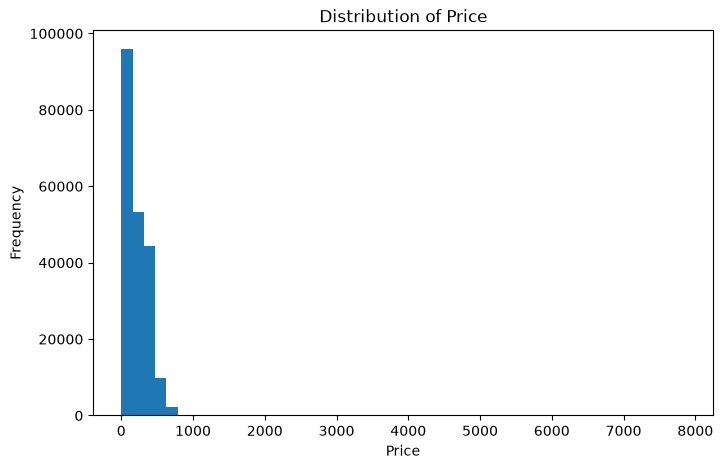

In [65]:
# Distribution of Price (P)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")
plt.show()

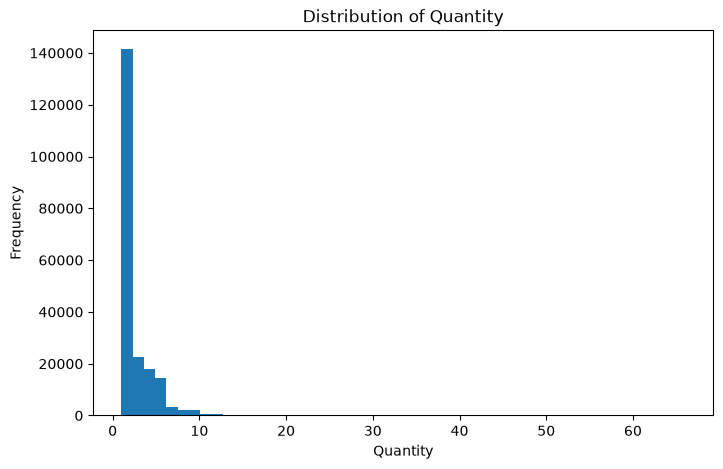

In [66]:
# Distribution of Quantity (Q)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

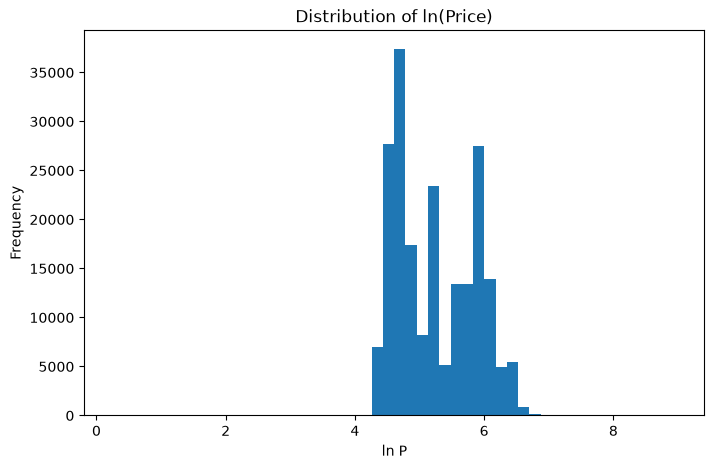

In [67]:
# Distribution of Log of Price (ln P)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["ln_price"], bins=50)
plt.xlabel("ln P")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Price)")
plt.show()

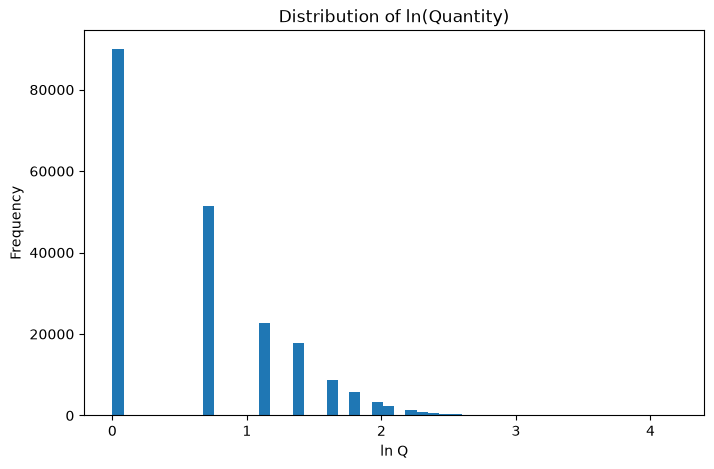

In [68]:
# Distribution of Log of Quantity (ln Q)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["ln_quantity"], bins=50)
plt.xlabel("ln Q")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Quantity)")
plt.show()

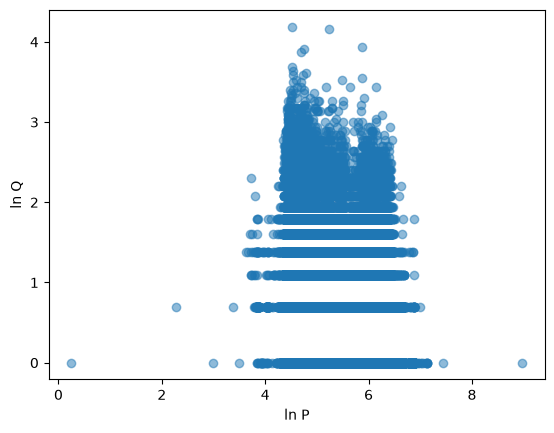

In [69]:
# Scatter plot of ln Q against ln P
plt.scatter(agg_df["ln_price"], agg_df["ln_quantity"], alpha=0.5)
plt.xlabel("ln P")
plt.ylabel("ln Q")
plt.show()

## OLS

In [70]:
def perform_ols(df):
    # Dependent variable
    y = df["ln_quantity"]

    # Independent variables
    X = df[[
        "ln_price",
        "train_num",
        "is_norm_cabin",
        "is_return",
        "is_oneway",
        "customer_cat",
        "days_in_advance",
        "dept_month_of_year",
        "dept_day_of_week"
    ]]

    # Convert categorical variables to dummy variables
    X = pd.get_dummies(
        X,
        columns=[
            "train_num",
            "customer_cat",
            "dept_month_of_year",
            "dept_day_of_week"
        ],
        drop_first=True
    )

    # Add intercept
    X = sm.add_constant(X)

    display(X)

    return sm.OLS(y, X).fit()

### Without Aggregation

In [71]:
non_agg_ols_model = perform_ols(non_agg_df)

,const,ln_price,is_norm_cabin,is_return,is_oneway,days_in_advance,train_num_B,train_num_C,train_num_D,train_num_E,...,dept_month_of_year_9,dept_month_of_year_10,dept_month_of_year_11,dept_month_of_year_12,dept_day_of_week_Monday,dept_day_of_week_Saturday,dept_day_of_week_Sunday,dept_day_of_week_Thursday,dept_day_of_week_Tuesday,dept_day_of_week_Wednesday
0,1.0,5.239965,1,0,0,364,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,1.0,5.881730,0,1,0,355,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1.0,5.875977,0,1,0,349,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1.0,5.982349,0,1,0,348,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
4,1.0,5.897880,0,1,0,347,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209692,1.0,6.149856,0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
209693,1.0,6.149876,0,0,1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
209694,1.0,6.504381,0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
209695,1.0,5.943950,0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [72]:
non_agg_ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     974.6
Date:               Thu, 10 Sept 2026   Prob (F-statistic):               0.00
Time:                        16:55:41   Log-Likelihood:            -1.9424e+05
No. Observations:              209697   AIC:                         3.886e+05
Df Residuals:                  209659   BIC:                         3.889e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.3164      0.024     54.868      0.000       1.269       1.363
ln_price                      -0.1957      0.004    -52.166      0.000      -0.203      -0.188
is_norm_cabin                 -0.0501      0.004    -12.557      0.000      -0.058      -0.042
is_return                      0.0112      0.004      2.578      0.010       0.003       0.020
is_oneway                     -0.0725      0.004    -17.283      0.000      -0.081      -0.064
days_in_advance                0.0005   2.65e-05     19.848      0.000       0.000       0.001
train_num_B                    0.1790      0.008     23.746      0.000       0.164       0.194
train_num_C                    0.0890      0.008     10.694      0.000       0.073       0.105
train_num_D                    0.0132      0.008      1.575      0.115      -0.003       0.030
train_num_E                    0.2001      0.007     29.649      0.000       0.187       0.213
train_num_F                    0.1415      0.007     19.733      0.000       0.127       0.156
train_num_G                    0.1343      0.008     17.494      0.000       0.119       0.149
train_num_H                    0.1459      0.007     20.486      0.000       0.132       0.160
train_num_I                    0.0605      0.008      7.584      0.000       0.045       0.076
train_num_J                    0.0186      0.008      2.410      0.016       0.003       0.034
train_num_K                   -0.0516      0.010     -5.269      0.000      -0.071      -0.032
train_num_L                    0.0073      0.010      0.754      0.451      -0.012       0.026
train_num_M                   -0.1038      0.008    -12.386      0.000      -0.120      -0.087
train_num_N                   -0.1746      0.014    -12.503      0.000      -0.202      -0.147
train_num_O                   -0.5716      0.611     -0.935      0.350      -1.769       0.626
customer_cat_B                 0.2730      0.004     72.060      0.000       0.266       0.280
dept_month_of_year_2          -0.0321      0.007     -4.457      0.000      -0.046      -0.018
dept_month_of_year_3           0.0827      0.006     12.946      0.000       0.070       0.095
dept_month_of_year_4           0.0368      0.007      5.314      0.000       0.023       0.050
dept_month_of_year_5          -0.0076      0.007     -1.151      0.250      -0.021       0.005
dept_month_of_year_6           0.0977      0.006     15.477      0.000       0.085       0.110
dept_month_of_year_7          -0.0553      0.007     -8.505      0.000      -0.068      -0.043
dept_month_of_year_8          -0.0279      0.007     -4.098      0.000      -0.041      -0.015
dept_month_of_year_9          -0.0543      0.007     -8.181      0.000      -0.067      -0.041
dept_month_of_year_10         -0.0357      

### With Aggregation

In [73]:
agg_ols_model = perform_ols(agg_df)

,const,ln_price,is_norm_cabin,is_return,is_oneway,days_in_advance,train_num_B,train_num_C,train_num_D,train_num_E,...,dept_month_of_year_9,dept_month_of_year_10,dept_month_of_year_11,dept_month_of_year_12,dept_day_of_week_Monday,dept_day_of_week_Saturday,dept_day_of_week_Sunday,dept_day_of_week_Thursday,dept_day_of_week_Tuesday,dept_day_of_week_Wednesday
0,1.0,6.035685,0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.0,6.417307,0,0,1,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.0,6.008635,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.0,6.334568,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,6.363786,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206268,1.0,5.231469,1,1,1,354,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
206269,1.0,4.614339,1,0,0,349,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
206270,1.0,5.843385,0,0,0,350,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
206271,1.0,5.179893,1,1,0,354,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [74]:
agg_ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     868.7
Date:               Thu, 10 Sept 2026   Prob (F-statistic):               0.00
Time:                        16:55:44   Log-Likelihood:            -1.9351e+05
No. Observations:              206273   AIC:                         3.871e+05
Df Residuals:                  206235   BIC:                         3.875e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.3617      0.025     55.511      0.000       1.314       1.410
ln_price                      -0.1970      0.004    -51.406      0.000      -0.205      -0.189
is_norm_cabin                 -0.0714      0.004    -17.514      0.000      -0.079      -0.063
is_return                      0.0134      0.004      3.042      0.002       0.005       0.022
is_oneway                     -0.0828      0.004    -19.450      0.000      -0.091      -0.074
days_in_advance                0.0005   2.69e-05     17.315      0.000       0.000       0.001
train_num_B                    0.1800      0.008     23.442      0.000       0.165       0.195
train_num_C                    0.0944      0.009     11.096      0.000       0.078       0.111
train_num_D                    0.0101      0.009      1.179      0.238      -0.007       0.027
train_num_E                    0.2051      0.007     29.765      0.000       0.192       0.219
train_num_F                    0.1460      0.007     19.947      0.000       0.132       0.160
train_num_G                    0.1362      0.008     17.418      0.000       0.121       0.152
train_num_H                    0.1483      0.007     20.414      0.000       0.134       0.163
train_num_I                    0.0590      0.008      7.263      0.000       0.043       0.075
train_num_J                    0.0186      0.008      2.359      0.018       0.003       0.034
train_num_K                   -0.0595      0.010     -5.958      0.000      -0.079      -0.040
train_num_L                    0.0043      0.010      0.431      0.666      -0.015       0.024
train_num_M                   -0.1041      0.009    -12.168      0.000      -0.121      -0.087
train_num_N                   -0.1875      0.014    -13.157      0.000      -0.215      -0.160
train_num_O                   -0.5981      0.618     -0.967      0.333      -1.810       0.614
customer_cat_B                 0.2618      0.004     67.276      0.000       0.254       0.269
dept_month_of_year_2          -0.0328      0.007     -4.468      0.000      -0.047      -0.018
dept_month_of_year_3           0.0830      0.007     12.720      0.000       0.070       0.096
dept_month_of_year_4           0.0369      0.007      5.219      0.000       0.023       0.051
dept_month_of_year_5          -0.0068      0.007     -1.010      0.312      -0.020       0.006
dept_month_of_year_6           0.1001      0.006     15.529      0.000       0.088       0.113
dept_month_of_year_7          -0.0587      0.007     -8.844      0.000      -0.072      -0.046
dept_month_of_year_8          -0.0313      0.007     -4.511      0.000      -0.045      -0.018
dept_month_of_year_9          -0.0567      0.007     -8.381      0.000      -0.070      -0.043
dept_month_of_year_10         -0.0394      

## 2SLS

In [75]:
def perform_tsls(df):
    return IV2SLS.from_formula(
        """
        ln_quantity ~ 1
            + is_norm_cabin
            + is_return
            + is_oneway
            + C(customer_cat)
            + C(train_num)
            + C(dept_month_of_year)
            + C(dept_day_of_week)
            + [ln_price ~ days_in_advance]
        """,
        data=df
    ).fit()

### Without Aggregation

In [76]:
non_agg_tsls_model = perform_tsls(non_agg_df)

In [77]:
non_agg_tsls_model.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                      0.1374
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1373
No. Observations:              209697   F-statistic:                 2.249e+05
Date:               Thu, Sept 10 2026   P-value (F-stat)                0.0000
Time:                        16:55:47   Distribution:                 chi2(36)
Cov. Estimator:                robust                                         
                                                                              
                                        Parameter Estimates                                         
====================================================================================================
                                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------------
Intercept                            2.3945     0.0512     46.759     0.0000      2.2941      2.4949
is_norm_cabin                       -0.1622     0.0069    -23.499     0.0000     -0.1757     -0.1486
is_return                            0.0036     0.0043     0.8421     0.3997     -0.0048      0.0121
is_oneway                           -0.0512     0.0043    -12.048     0.0000     -0.0596     -0.0429
C(customer_cat)[T.B]                 0.2333     0.0042     55.654     0.0000      0.2251      0.2416
C(train_num)[T.B]                    0.1877     0.0075     25.110     0.0000      0.1731      0.2024
C(train_num)[T.C]                    0.1319     0.0084     15.701     0.0000      0.1154      0.1483
C(train_num)[T.D]                    0.0254     0.0081     3.1441     0.0017      0.0096      0.0413
C(train_num)[T.E]                    0.1930     0.0068     28.239     0.0000      0.1796      0.2064
C(train_num)[T.F]                    0.1434     0.0071     20.113     0.0000      0.1294      0.1574
C(train_num)[T.G]                    0.1391     0.0076     18.371     0.0000      0.1243      0.1540
C(train_num)[T.H]                    0.1419     0.0071     19.998     0.0000      0.1280      0.1558
C(train_num)[T.I]                    0.0723     0.0077     9.3657     0.0000      0.0572      0.0875
C(train_num)[T.J]                    0.0151     0.0075     2.0169     0.0437      0.0004      0.0297
C(train_num)[T.K]                   -0.0390     0.0091    -4.2788     0.0000     -0.0569     -0.0211
C(train_num)[T.L]                    0.0377     0.0091     4.1261     0.0000      0.0198      0.0557
C(train_num)[T.M]                   -0.1096     0.0079    -13.933     0.0000     -0.1250     -0.0942
C(train_num)[T.N]                   -0.1448     0.0100    -14.412     0.0000     -0.1645     -0.1251
C(train_num)[T.O]                   -0.4810     0.0108    -44.512     0.0000     -0.5021     -0.4598
C(dept_month_of_year)[T.2]          -0.0318     0.0070    -4.5197     0.0000     -0.0456     -0.0180
C(dept_month_of_year)[T.3]           0.0682     0.0065     10.522     0.0000      0.0555      0.0809
C(dept_month_of_year)[T.4]           0.0343     0.0068     5.0442     0.0000      0.0210      0.0477
C(dept_month_of_year)[T.5]          -0.0213     0.0064    -3.3387     0.0008     -0.0338     -0.0088
C(dept_month_of_year)[T.6]           0.0994     0.0063     15.727     0.0000      0.0870      0.1118
C(dept_month_of_year)[T.7]          -0.0725     0.0062    -11.675     0.0000     -0.0847     -0.0604
C(dept_month_of_year)[T.8]          -0.0308     0.0067    -4.5828     0.0000     -0.0440     -0.0176
C(dept_month_of_year)[T.9]          -0.0737     0.0065    -11.352     0.0000     -0.0864     -0.0609
C(dept_month_of_year)[T.10]         -0.0474     0.0063    -7.5379     0.0000     -0.0597     -0.0350
C(d

In [78]:
non_agg_tsls_model.first_stage

,ln_price
R-squared,0.6588
Partial R-squared,0.1720
Shea's R-squared,0.1720
Partial F-statistic,2.74e+04
P-value (Partial F-stat),0.0000
Partial F-stat Distn,chi2(1)
==================================,===========
Intercept,6.0044
,(1259.8)
is_norm_cabin,-0.6240


In [79]:
non_agg_tsls_model.wu_hausman()

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 393.9339
P-value: 0.0000
Distributed: F(1,209659)
WaldTestStatistic, id: 0x1ea5d3dd050

### With Aggregation

In [80]:
agg_tsls_model = perform_tsls(agg_df)

In [81]:
agg_tsls_model.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                      0.1276
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1274
No. Observations:              206273   F-statistic:                 2.267e+05
Date:               Thu, Sept 10 2026   P-value (F-stat)                0.0000
Time:                        16:56:05   Distribution:                 chi2(36)
Cov. Estimator:                robust                                         
                                                                              
                                        Parameter Estimates                                         
====================================================================================================
                                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------------
Intercept                            2.3212     0.0518     44.770     0.0000      2.2196      2.4228
is_norm_cabin                       -0.1712     0.0070    -24.499     0.0000     -0.1849     -0.1575
is_return                            0.0068     0.0044     1.5613     0.1185     -0.0017      0.0154
is_oneway                           -0.0639     0.0043    -14.891     0.0000     -0.0724     -0.0555
C(customer_cat)[T.B]                 0.2256     0.0043     52.013     0.0000      0.2171      0.2342
C(train_num)[T.B]                    0.1877     0.0076     24.729     0.0000      0.1729      0.2026
C(train_num)[T.C]                    0.1334     0.0086     15.503     0.0000      0.1165      0.1503
C(train_num)[T.D]                    0.0209     0.0082     2.5410     0.0111      0.0048      0.0370
C(train_num)[T.E]                    0.1988     0.0070     28.493     0.0000      0.1851      0.2125
C(train_num)[T.F]                    0.1479     0.0073     20.316     0.0000      0.1336      0.1621
C(train_num)[T.G]                    0.1404     0.0077     18.251     0.0000      0.1254      0.1555
C(train_num)[T.H]                    0.1447     0.0072     20.022     0.0000      0.1305      0.1588
C(train_num)[T.I]                    0.0695     0.0078     8.8617     0.0000      0.0541      0.0849
C(train_num)[T.J]                    0.0155     0.0076     2.0308     0.0423      0.0005      0.0304
C(train_num)[T.K]                   -0.0483     0.0093    -5.2185     0.0000     -0.0664     -0.0302
C(train_num)[T.L]                    0.0322     0.0095     3.4039     0.0007      0.0137      0.0508
C(train_num)[T.M]                   -0.1091     0.0080    -13.586     0.0000     -0.1249     -0.0934
C(train_num)[T.N]                   -0.1610     0.0104    -15.539     0.0000     -0.1813     -0.1407
C(train_num)[T.O]                   -0.5176     0.0110    -47.228     0.0000     -0.5390     -0.4961
C(dept_month_of_year)[T.2]          -0.0325     0.0072    -4.5240     0.0000     -0.0466     -0.0184
C(dept_month_of_year)[T.3]           0.0699     0.0066     10.564     0.0000      0.0569      0.0829
C(dept_month_of_year)[T.4]           0.0348     0.0070     4.9969     0.0000      0.0211      0.0484
C(dept_month_of_year)[T.5]          -0.0190     0.0065    -2.9070     0.0036     -0.0318     -0.0062
C(dept_month_of_year)[T.6]           0.1019     0.0065     15.744     0.0000      0.0892      0.1145
C(dept_month_of_year)[T.7]          -0.0742     0.0064    -11.676     0.0000     -0.0867     -0.0618
C(dept_month_of_year)[T.8]          -0.0339     0.0069    -4.9443     0.0000     -0.0474     -0.0205
C(dept_month_of_year)[T.9]          -0.0742     0.0066    -11.205     0.0000     -0.0872     -0.0612
C(dept_month_of_year)[T.10]         -0.0499     0.0064    -7.7935     0.0000     -0.0625     -0.0374
C(d

In [82]:
agg_tsls_model.first_stage

,ln_price
R-squared,0.6595
Partial R-squared,0.1727
Shea's R-squared,0.1727
Partial F-statistic,2.718e+04
P-value (Partial F-stat),0.0000
Partial F-stat Distn,chi2(1)
==================================,===========
Intercept,6.0092
,(1247.4)
is_norm_cabin,-0.6254


In [83]:
agg_tsls_model.wu_hausman()

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 299.8090
P-value: 0.0000
Distributed: F(1,206235)
WaldTestStatistic, id: 0x1ea5d420450